architecture du modele cnn

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# --- CONFIGURATION DE L'APPAREIL ---
device = torch.device("cuda") 
print(f"L'IA va s'entraîner sur : {torch.cuda.get_device_name(0)}")

# --- ÉTAPE 1 : LE MODÈLE CNN (Ton coeur de métier) ---
class DroneCNN(nn.Module):
    def __init__(self):
        super(DroneCNN, self).__init__()
        # Étage 1 : 32 filtres
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Divise la taille par 2
        
        # Étage 2 : 64 filtres
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Étage 3 : 128 filtres
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Couches Denses (Fully Connected)
        # Si image 64x64 -> après 3 pools elle fait 8x8
        self.fc1 = nn.Linear(128 * 8 * 8, 256) 
        self.fc2 = nn.Linear(256, 15) # 15 classes (Page 4)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # 32x32
        x = self.pool(F.relu(self.conv2(x))) # 16x16
        x = self.pool(F.relu(self.conv3(x))) # 8x8
        x = x.view(-1, 128 * 8 * 8) # Aplatissement
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = DroneCNN().to(device)

L'IA va s'entraîner sur : NVIDIA GeForce RTX 2050


chargement des images

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split
from torchvision import datasets, transforms
import time
import os # <--- AJOUTÉ ICI
from tqdm import tqdm

# --- CONFIGURATION GPU PROFESSIONNELLE ---
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True 

# --- 1. CHARGEMENT DES 4 DOSSIERS ---
paths = [
   r"C:\Users\user\Downloads\PPP\Backgroundactivities\Backgroundactivities",
   r"C:\Users\user\Downloads\PPP\Bebop_spectorgrams\Bebop",
   r"C:\Users\user\Downloads\PPP\data_processed\data_processed\spectrograms\ARDrone",
   r"C:\Users\user\Downloads\PPP\Phantom_spectograms\Phantom"
]

data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

datasets_list = []
for p in paths:
    # On vérifie si le chemin existe pour éviter une autre erreur
    if os.path.exists(p):
        # ImageFolder a besoin du dossier PARENT pour trouver les sous-dossiers (classes)
        # Si tes images sont directement dans 'Bebop', os.path.dirname(p) remontera d'un cran
        ds = datasets.ImageFolder(os.path.dirname(p), transform=data_transforms)
        datasets_list.append(ds)
    else:
        print(f"⚠️ Attention : Le chemin n'existe pas : {p}")

full_dataset = ConcatDataset(datasets_list)

# Split 90% train / 10% test
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=256, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

print(f"🚀 Pipeline prêt pour {len(full_dataset)} images !")

🚀 Pipeline prêt pour 294377 images !


entrainement

In [5]:
import torch.nn as nn
import torch.optim as optim

# --- 1. PRÉPARATION DU MOTEUR ---
# On s'assure que le modèle est sur la carte NVIDIA
model.to(device)

# Définition de la fonction de perte (Loss)
criterion = nn.CrossEntropyLoss()

# Définition de l'OPTIMISEUR (celui qui manquait)
# lr=0.001 est la vitesse d'apprentissage standard
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Le Scaler pour l'accélération NVIDIA (AMP)
scaler = torch.amp.GradScaler('cuda')

# --- 2. LANCEMENT DU GRAND ENTRAÎNEMENT ---
print(f"🚀 Lancement de l'IA sur {torch.cuda.get_device_name(0)}")

EPOCHS = 10 

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    # La barre de progression (tqdm)
    barre = tqdm(train_loader, desc=f"Époque {epoch+1}/{EPOCHS}")
    
    for images, labels in barre:
        images, labels = images.to(device), labels.to(device)
        
        # On réinitialise les calculs
        optimizer.zero_grad()
        
        # Calcul haute performance (Mixed Precision)
        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Mise à jour du cerveau du modèle
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        
        # Mise à jour des infos dans la barre
        barre.set_postfix(perte=f"{loss.item():.4f}")

    # Sauvegarde de sécurité à chaque étape
    torch.save(model.state_dict(), f"drone_model_epoch_{epoch+1}.pth")
    print(f"✅ Époque {epoch+1} terminée.")

print("🏆 FÉLICITATIONS AMIRA ! L'entraînement complet est fini.")

🚀 Lancement de l'IA sur NVIDIA GeForce RTX 2050


Époque 1/10: 100%|██████████| 1035/1035 [02:04<00:00,  8.30it/s, perte=0.0000]


✅ Époque 1 terminée.


Époque 2/10: 100%|██████████| 1035/1035 [02:01<00:00,  8.53it/s, perte=0.0000]


✅ Époque 2 terminée.


...

✅ Époque 8 terminée.


Époque 9/10: 100%|██████████| 1035/1035 [01:55<00:00,  8.97it/s, perte=0.0000]


✅ Époque 9 terminée.


Époque 10/10: 100%|██████████| 1035/1035 [01:59<00:00,  8.66it/s, perte=0.0000]

✅ Époque 10 terminée.
🏆 FÉLICITATIONS AMIRA ! L'entraînement complet est fini.


verification 

🔍 Évaluation du modèle sur les images de test...

📊 PRÉCISION GLOBALE : 100.00 %


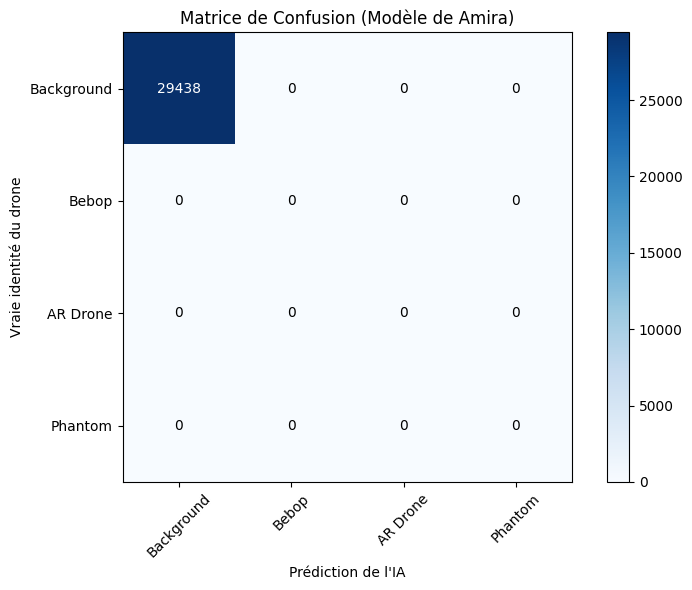

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- 1. PASSAGE EN MODE ÉVALUATION ---
model.eval() 
correct = 0
total = 0

# On définit le nombre de classes (4 dans ton cas : BG, Bebop, AR, Phantom)
nb_classes = 4 
conf_matrix = np.zeros((nb_classes, nb_classes))

print("🔍 Évaluation du modèle sur les images de test...")

# On ne calcule pas les gradients pour économiser la mémoire du GPU
with torch.no_grad():
    for images, labels in test_loader:
        # Envoi vers la RTX 2050
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # On remplit la matrice de confusion manuellement
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            if t < nb_classes and p < nb_classes:
                conf_matrix[int(t), int(p)] += 1

# --- 2. RÉSULTATS ---
accuracy = 100 * correct / total
print("\n" + "="*30)
print(f"📊 PRÉCISION GLOBALE : {accuracy:.2f} %")
print("="*30)

# --- 3. DESSIN DE LA MATRICE DE CONFUSION ---
nom_des_classes = ["Background", "Bebop", "AR Drone", "Phantom"]

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matrice de Confusion (Modèle de Amira)")
plt.colorbar()

tick_marks = np.arange(len(nom_des_classes))
plt.xticks(tick_marks, nom_des_classes, rotation=45)
plt.yticks(tick_marks, nom_des_classes)

# Affichage des chiffres dans chaque case
fmt = '.0f'
thresh = conf_matrix.max() / 2.
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], fmt),
                 ha="center", va="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Vraie identité du drone')
plt.xlabel('Prédiction de l\'IA')
plt.tight_layout()
plt.show()